In [ ]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 불러오기 + 한글 폰트 + 시드 고정 
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# !pip install numpy pandas matplotlib seaborn -q

import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False   # 마이너스 부호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)

준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.5.0
pandas: 3.0.3


In [2]:
# ─────────────────────────────────────────────
# 모두마켓 데이터 생성 — 이 셀 하나로 오늘 쓸 데이터가 모두 준비됩니다.
# (실제 현장처럼 '텍스트·날짜 오염'을 일부러 심어 둡니다)
# ─────────────────────────────────────────────
np.random.seed(42)

# 1) 고객(customers) -------------------------------------------------
n_customers = 200
last_names = ["김", "이", "박", "최", "정", "강", "조", "윤", "장", "임"]
first_names = ["민준", "서연", "도윤", "지우", "하준", "서윤", "예준", "지유", "주원", "지호"]
names = [np.random.choice(last_names) + np.random.choice(first_names) for _ in range(n_customers)]
# 이름 일부에 앞뒤 공백 오염
for i in np.random.choice(n_customers, 15, replace=False):
    names[i] = "  " + names[i] + " "

# 이메일: 대소문자 + 앞뒤 공백 오염
domains = ["gmail.com", "naver.com", "MODUMARKET.com", "daum.net", "kakao.com"]
emails = []
for i in range(n_customers):
    e = f"user{i+1:03d}@{np.random.choice(domains)}"
    r = np.random.random()
    if r < 0.20:
        e = e.upper()              # 전체 대문자
    elif r < 0.35:
        e = "  " + e + " "         # 앞뒤 공백
    emails.append(e)

# 전화번호: 네 가지 형식 혼재
def make_phone(i):
    mid, end = np.random.randint(1000, 9999), np.random.randint(1000, 9999)
    fmt = i % 4
    if fmt == 0:
        return f"010-{mid}-{end}"
    if fmt == 1:
        return f"010{mid}{end}"
    if fmt == 2:
        return f"010.{mid}.{end}"
    return f"+82 10 {mid} {end}"
phones = [make_phone(i) for i in range(n_customers)]

# 지역: 표기 혼재(공백·영문)
region = np.random.choice(
    ["서울", " 서울 ", "Seoul", "경기", "부산", "인천", "대구"],
    n_customers, p=[0.30, 0.05, 0.05, 0.25, 0.15, 0.10, 0.10])

# 가입일: 네 가지 날짜 포맷 혼재(문자열로 저장)
signup_base = pd.to_datetime("2024-01-01") + pd.to_timedelta(np.random.randint(0, 365, n_customers), unit="D")
signup = []
for i, d in enumerate(signup_base):
    f = i % 4
    if f == 0:
        signup.append(d.strftime("%Y-%m-%d"))
    elif f == 1:
        signup.append(d.strftime("%Y/%m/%d"))
    elif f == 2:
        signup.append(d.strftime("%Y.%m.%d"))
    else:
        signup.append(d.strftime("%Y%m%d"))

customers = pd.DataFrame({
    "customer_id": [f"C{i+1:04d}" for i in range(n_customers)],
    "name": names,
    "email": emails,
    "phone": phones,
    "region": region,
    "signup_date": signup,
})

# 2) 주문(orders) ----------------------------------------------------
catalog = [("무선 이어폰", "P-1001", 89000), ("블루투스 스피커", "P-1002", 49000),
           ("노트북 거치대", "P-1003", 29000), ("기계식 키보드", "P-1004", 119000),
           ("USB-C 충전기", "P-1005", 19000), ("보조배터리", "P-1006", 39000),
           ("스마트워치", "P-1007", 159000), ("액션캠", "P-1008", 229000)]
n_orders = 2000
pick = np.random.randint(0, len(catalog), n_orders)

product_name, amount = [], []
for j in pick:
    name, codeid, price = catalog[j]
    label = f"{name} ({codeid})"
    r = np.random.random()
    if r < 0.18:
        label = "  " + label + "  "        # 앞뒤 공백
    elif r < 0.30:
        label = label.replace(" ", "  ")    # 단어 사이 이중 공백
    product_name.append(label)
    amount.append(price * np.random.choice([1, 1, 1, 2, 3]))

coupon = np.random.choice(
    ["SALE2025", "WELCOME10", "VIP-2025", "summer25", "FREESHIP", ""],
    n_orders, p=[0.18, 0.15, 0.10, 0.10, 0.07, 0.40])

channel = np.random.choice(["web", "app", "app ", "APP"], n_orders, p=[0.45, 0.45, 0.05, 0.05])

# 주문 일시: 두 가지 포맷 혼재 + 소수의 오류값
dt_base = pd.to_datetime("2025-01-01") + pd.to_timedelta(np.random.randint(0, 90 * 24 * 3600, n_orders), unit="s")
order_datetime = []
for i, d in enumerate(dt_base):
    if i % 2 == 0:
        order_datetime.append(d.strftime("%Y-%m-%d %H:%M:%S"))
    else:
        order_datetime.append(d.strftime("%Y/%m/%d %H:%M:%S"))
# 오류값 심기: 파싱 불가능한 문자열 12건
for i in np.random.choice(n_orders, 12, replace=False):
    order_datetime[i] = np.random.choice(["처리중", "-", "unknown"])

orders = pd.DataFrame({
    "order_id": [f"O{i+1:05d}" for i in range(n_orders)],
    "customer_id": np.random.choice(customers["customer_id"], n_orders),
    "product_name": product_name,
    "amount": amount,
    "coupon": coupon,
    "channel": channel,
    "order_datetime": order_datetime,
})

print("모두마켓 데이터 생성 완료")
print("customers:", customers.shape, "| orders:", orders.shape)

모두마켓 데이터 생성 완료
customers: (200, 6) | orders: (2000, 7)


In [3]:
# 데이터가 어떻게 '오염'되어 있는지 맨 위 몇 줄을 직접 봅니다.
print("=== customers (고객) ===")
display(customers.head())
print("\n=== orders (주문) ===")
display(orders.head())

=== customers (고객) ===


,customer_id,name,email,phone,region,signup_date
0,C0001,조지우,user001@daum.net,010-8973-9577,경기,2024-04-27
1,C0002,윤하준,user002@gmail.com,01090709666,서울,2024/09/26
2,C0003,조지호,USER003@NAVER.COM,010.9609.7490,서울,2024.03.20
3,C0004,박예준,USER004@KAKAO.COM,+82 10 4600 7783,인천,20240402
4,C0005,윤하준,USER005@KAKAO.COM,010-5971-2205,대구,2024-09-22



=== orders (주문) ===


,order_id,customer_id,product_name,amount,coupon,channel,order_datetime
0,O00001,C0131,무선 이어폰 (P-1001),89000,FREESHIP,app,2025-01-01 23:12:56
1,O00002,C0094,USB-C 충전기 (P-1005),57000,WELCOME10,web,2025/01/25 12:15:09
2,O00003,C0008,기계식 키보드 (P-1004),357000,,web,2025-01-31 14:14:25
3,O00004,C0086,블루투스 스피커 (P-1002),147000,,app,2025/03/30 02:12:54
4,O00005,C0089,무선 이어폰 (P-1001),89000,,web,2025-02-18 23:06:24


In [4]:
# 예제: 정제 전 — region을 그냥 세면 같은 서울이 쪼개진다
print("[정제 전] region 값의 종류")
print(customers["region"].value_counts())
# repr로 보면 숨은 공백이 보입니다.
print("\n숨은 공백 확인:", [repr(x) for x in customers["region"].unique()])

[정제 전] region 값의 종류
region
경기       61
서울       52
부산       32
인천       19
대구       18
Seoul    10
 서울       8
Name: count, dtype: int64

숨은 공백 확인: ["'경기'", "'서울'", "'인천'", "'대구'", "'부산'", "'Seoul'", "' 서울 '"]


In [5]:
# 예제: strip → lower → replace 3단계로 region 통일하기
clean_region = (
    customers["region"]
    .str.strip()                      # 1) 앞뒤 공백 제거
    .str.replace("Seoul", "서울")      # 2) 영문 표기를 한글로 치환
)
customers["region_clean"] = clean_region

print("[정제 후] region_clean 값의 종류")
print(customers["region_clean"].value_counts())

[정제 후] region_clean 값의 종류
region_clean
서울    70
경기    61
부산    32
인천    19
대구    18
Name: count, dtype: int64


In [6]:
# 예제: 이메일 정제 — 앞뒤 공백 제거 + 소문자 통일
print("[정제 전] 이메일 일부(repr로 공백 노출)")
print([repr(x) for x in customers["email"].head(6)])

customers["email_clean"] = customers["email"].str.strip().str.lower()

print("\n[정제 후]")
print(customers["email_clean"].head(6).tolist())

[정제 전] 이메일 일부(repr로 공백 노출)
["'  user001@daum.net '", "'  user002@gmail.com '", "'USER003@NAVER.COM'", "'USER004@KAKAO.COM'", "'USER005@KAKAO.COM'", "'user006@kakao.com'"]

[정제 후]
['user001@daum.net', 'user002@gmail.com', 'user003@naver.com', 'user004@kakao.com', 'user005@kakao.com', 'user006@kakao.com']


스스로 해보자! ✏️ (1)
정답은 하나가 아닙니다. 일단 실행해보세요.

orders의 channel 컬럼에는 'web', 'app', 'app '(뒤 공백), 'APP'(대문자)이 섞여 있습니다.

(따라하기) channel을 그냥 value_counts()로 세어, 같은 앱이 어떻게 쪼개지는지 확인하세요.

(응용) .str.strip().str.lower()로 정제한 channel_clean 컬럼을 만들고 다시 세어보세요.

(생각해보기) 만약 정제하지 않은 채 "앱 주문 비율"을 보고했다면, 어떤 잘못된 결론이 나올까요?
- 실제 결과보다 적은 비율이 나올 것이고, 데이터 분석을 잘못 한 예시.

In [8]:
# 스스로 해보자! (1)
# 아래 주석(#)을 지우고 빈칸(___)을 채운 뒤 실행해보세요.

print("[정제 전]")
print(orders["channel"].value_counts())

orders["channel_clean"] = orders["channel"].str.strip().str.lower()   # strip, lower
print("\n[정제 후]")
print(orders["channel_clean"].value_counts())

[정제 전]
channel
web     919
app     902
app      98
APP      81
Name: count, dtype: int64

[정제 후]
channel_clean
app    1081
web     919
Name: count, dtype: int64


### .str.strip(), .str.lower(), .str.replace()는 각각 어떤 오염을 정리하나요?
- 공백 제거, 대문자->소문자, a를 b로 치환

### 정제 전에 repr()로 원본을 보는 이유는 무엇인가요?
- 공백을 노출시키기 위함

### .str.strip().str.lower()처럼 점으로 이어 붙이면 적용 순서는 어떻게 되나요?
-  왼쪽부터 차례로 적용

In [9]:
# 예제: contains — 특정 도메인 고객만 필터링
is_gmail = customers["email_clean"].str.contains("gmail")   # 불리언 Series
print("gmail 사용 고객 수:", is_gmail.sum())

gmail_customers = customers[is_gmail]                       # 불리언 필터링(D+003 복습)
print(gmail_customers[["customer_id", "email_clean"]].head())

gmail 사용 고객 수: 39
   customer_id        email_clean
1        C0002  user002@gmail.com
9        C0010  user010@gmail.com
10       C0011  user011@gmail.com
12       C0013  user013@gmail.com
19       C0020  user020@gmail.com


In [10]:
# 예제: split — @ 기준으로 쪼개 도메인만 추출
domain = customers["email_clean"].str.split("@").str[1]   # 쪼갠 리스트의 [1]번째 = 도메인
customers["domain"] = domain

print("[도메인별 고객 분포]")
print(customers["domain"].value_counts())

[도메인별 고객 분포]
domain
naver.com         46
kakao.com         42
gmail.com         39
modumarket.com    37
daum.net          36
Name: count, dtype: int64


In [11]:
# 예제: 슬라이싱 + startswith — 전화번호 앞 3자리 확인
print("전화번호 앞 3자리(원본 그대로):")
print(customers["phone"].str[0:3].value_counts().head())

# '+82'로 시작하는 국제 표기는 몇 건인가?
intl = customers["phone"].str.startswith("+82")
print("\n'+82' 국제 표기 건수:", intl.sum())

전화번호 앞 3자리(원본 그대로):
phone
010    150
+82     50
Name: count, dtype: int64

'+82' 국제 표기 건수: 50


In [12]:
# 스스로 해보자! (2)
# 아래 주석(#)을 지우고 빈칸(___)을 채워보세요.

# 1) naver 포함 고객 수
print("naver 고객:", customers["email_clean"].str.contains("naver").sum())

# 2) 도메인이 modumarket.com 인 고객 (.str.split("@").str[1] 쪼갠 뒤 N번째 조각 선택)
customers["domain2"] = customers["email_clean"].str.split("@").str[1]
company = customers[customers["domain2"] == "modumarket.com"]
print("회사 메일 고객 수:", len(company))

naver 고객: 46
회사 메일 고객 수: 37



### .str.contains()의 결과는 어떤 자료형이고, 어디에 바로 쓸 수 있나요?
 참/거짓의 불리언(boolean). D+003에서 배운 불리언 필터링(df[조건])에 그대로 넣을 수 있어요.

### .str.split("@").str[1]은 무엇을 골라내나요?
쪼갠 뒤 1번째 조각 선택
### 단순 슬라이싱(.str[0:3])이 안전하려면 데이터가 어떤 조건을 만족해야 하나요?
  형식이 일정할 때만 

In [13]:
# 예제: replace로 전화번호에서 숫자만 남기기 (숫자가 아닌 모든 글자 삭제)
# [^0-9] = '숫자가 아닌' 글자, 이것을 빈 문자열로 치환 → 숫자만 남음
customers["phone_digits"] = customers["phone"].str.replace(r"[^0-9]", "", regex=True)

print("[정제 전 → 후]")
for before, after in zip(customers["phone"].head(4), customers["phone_digits"].head(4)):
    print(f"{before:<18} →  {after}")

[정제 전 → 후]
010-8973-9577      →  01089739577
01090709666        →  01090709666
010.9609.7490      →  01096097490
+82 10 4600 7783   →  821046007783


In [14]:
# 예제: extract로 상품명에서 상품 코드(P-숫자)만 뽑기
# 패턴 (P-\d+) = 'P-' 다음에 숫자가 1개 이상 → 괄호로 묶어 그 부분만 추출
orders["product_code"] = orders["product_name"].str.extract(r"(P-\d+)")

print(orders[["product_name", "product_code"]].head(6))

            product_name product_code
0      무선 이어폰 (P-1001)         P-1001
1     USB-C 충전기 (P-1005)       P-1005
2       기계식 키보드 (P-1004)       P-1004
3    블루투스 스피커 (P-1002)         P-1002
4        무선 이어폰 (P-1001)       P-1001
5         보조배터리 (P-1006)       P-1006


In [15]:
# 예제: findall로 쿠폰 코드의 '영문 대문자 묶음'과 '숫자 묶음' 분리해 보기
sample = pd.Series(["SALE2025", "WELCOME10", "VIP-2025", "summer25", ""])

print("대문자 알파벳 덩어리 찾기  [A-Z]+ :")
print(sample.str.findall(r"[A-Z]+").tolist())
print("\n숫자 덩어리 찾기  \\d+ :")
print(sample.str.findall(r"\d+").tolist())

대문자 알파벳 덩어리 찾기  [A-Z]+ :
[['SALE'], ['WELCOME'], ['VIP'], [], []]

숫자 덩어리 찾기  \d+ :
[['2025'], ['10'], ['2025'], ['25'], []]


In [ ]:
# 스스로 해보자! (3)
# 아래 주석(#)을 지우고 빈칸(___)을 채워보세요.

# 1) 쿠폰에서 숫자만 추출
orders["coupon_num"] = orders["coupon"].str.extract(r"(\d+)")   # 힌트: (\d+)
print(orders[["coupon", "coupon_num"]].head(8))

# 2) 전화번호 자릿수 분포
print(customers["phone_digits"].str.len().value_counts())     # 힌트: len

# d+와 [^0-9]는 어떻게 반대 개념인가요? 한 문장으로 설명해보세요.
# (\d+)는 숫자를 찾고, [^0-9]는 숫자가 아닌 문자를 찾습니다.

      coupon coupon_num
0   FREESHIP        NaN
1  WELCOME10         10
2                   NaN
3                   NaN
4                   NaN
5  WELCOME10         10
6                   NaN
7   SALE2025       2025
phone_digits
11    150
12     50
Name: count, dtype: int64


In [17]:
# 예제: 변환 전 — order_datetime은 그냥 문자열(object)
print("dtype:", orders["order_datetime"].dtype)   # object = 문자열
print(orders["order_datetime"].head(6).tolist())

# 이 상태에서는 '시간 차이' 같은 계산이 불가능합니다.
print("\n'문자열'이라 정렬해도 날짜 순서가 보장되지 않습니다.")

dtype: str
['2025-01-01 23:12:56', '2025/01/25 12:15:09', '2025-01-31 14:14:25', '2025/03/30 02:12:54', '2025-02-18 23:06:24', '2025/02/18 07:41:05']

'문자열'이라 정렬해도 날짜 순서가 보장되지 않습니다.


In [18]:
# 예제: format='mixed' + errors='coerce'로 안전하게 변환
orders["order_dt"] = pd.to_datetime(
    orders["order_datetime"],
    format="mixed",        # 행마다 다른 형식을 각자 추론
    errors="coerce",       # 변환 못 하면 NaT(결측 날짜)
)

print("변환 후 dtype:", orders["order_dt"].dtype)   # datetime64[ns]
print("변환 실패(NaT) 건수:", orders["order_dt"].isna().sum())   # 오류값 12건
print(orders[["order_datetime", "order_dt"]].head(6))

변환 후 dtype: datetime64[us]
변환 실패(NaT) 건수: 12
        order_datetime            order_dt
0  2025-01-01 23:12:56 2025-01-01 23:12:56
1  2025/01/25 12:15:09 2025-01-25 12:15:09
2  2025-01-31 14:14:25 2025-01-31 14:14:25
3  2025/03/30 02:12:54 2025-03-30 02:12:54
4  2025-02-18 23:06:24 2025-02-18 23:06:24
5  2025/02/18 07:41:05 2025-02-18 07:41:05


In [ ]:
# 예제: 구분자 통일 후 format 지정하기 (정제 → 파싱 연결)
# signup_date는 2024-03-15 / 2024/03/15 / 2024.03.15 / 20240315 가 섞여 있음
# 1단계: 정규식으로 구분자(- / .)를 모두 제거 → 'YYYYMMDD' 8자리로 통일 (Part 1~3 복습!)
digits_only = customers["signup_date"].str.replace(r"[^0-9]", "", regex=True) #제거

# 2단계: 형식을 명시해 파싱 (가장 정확)
customers["signup_dt"] = pd.to_datetime(digits_only, format="%Y%m%d", errors="coerce")

print(customers[["signup_date", "signup_dt"]].head(6))
print("\n변환 실패 건수:", customers["signup_dt"].isna().sum())

  signup_date  signup_dt
0  2024-04-27 2024-04-27
1  2024/09/26 2024-09-26
2  2024.03.20 2024-03-20
3    20240402 2024-04-02
4  2024-09-22 2024-09-22
5  2024/11/27 2024-11-27

변환 실패 건수: 0


In [ ]:
# 스스로 해보자! (4)
# 아래 주석(#)을 지우고 빈칸(___)을 채워보세요.

# 1) 기간 확인
print("가장 이른 주문:", orders["order_dt"].min())   # min
print("가장 늦은 주문:", orders["order_dt"].max())   # max

# 2) 파싱 실패 행의 원본 보기
failed = orders[orders["order_dt"].isna()]            # isna
print(failed["order_datetime"].value_counts())

# errors="coerce" 대신 아무 옵션도 안 줬다면 어떤 일이 벌어졌을까요?
# 오류값에서 멈춰버립니다

가장 이른 주문: 2025-01-01 00:36:15
가장 늦은 주문: 2025-03-31 23:20:27
order_datetime
-          4
처리중        4
unknown    4
Name: count, dtype: int64



### 문자열 "2025-01-12"와 datetime 2025-01-12는 컴퓨터 입장에서 무엇이 다른가요?
글자 덩어리 / 날짜형 자료
### format="mixed"와 errors="coerce"는 각각 어떤 상황을 위한 옵션인가요?
	행마다 형식이 다를 때 / 에러를 발견하면 멈추지 않고 Nat(결측)으로 처리

### NaT는 무엇이고, 숫자의 어떤 값에 해당하나요?
결측치. 숫자의 NaN과 같은 역할!

In [21]:
# 예제: 날짜에서 부품 꺼내 새 컬럼 만들기
valid = orders.dropna(subset=["order_dt"]).copy()   # NaT(파싱 실패) 제외

valid["year"] = valid["order_dt"].dt.year
valid["month"] = valid["order_dt"].dt.month
valid["hour"] = valid["order_dt"].dt.hour
valid["dow_num"] = valid["order_dt"].dt.dayofweek      # 0=월 ... 6=일
valid["dow_name"] = valid["order_dt"].dt.day_name()    # 영문 요일 이름

print(valid[["order_dt", "year", "month", "hour", "dow_num", "dow_name"]].head())

             order_dt  year  month  hour  dow_num   dow_name
0 2025-01-01 23:12:56  2025      1    23        2  Wednesday
1 2025-01-25 12:15:09  2025      1    12        5   Saturday
2 2025-01-31 14:14:25  2025      1    14        4     Friday
3 2025-03-30 02:12:54  2025      3     2        6     Sunday
4 2025-02-18 23:06:24  2025      2    23        1    Tuesday


In [ ]:
# 예제: 날짜에서 부품 꺼내 새 컬럼 만들기 .dt
valid = orders.dropna(subset=["order_dt"]).copy()   # NaT(파싱 실패) 제외

valid["year"] = valid["order_dt"].dt.year
valid["month"] = valid["order_dt"].dt.month
valid["hour"] = valid["order_dt"].dt.hour
valid["dow_num"] = valid["order_dt"].dt.dayofweek      # 0=월 ... 6=일
valid["dow_name"] = valid["order_dt"].dt.day_name()    # 영문 요일 이름

print(valid[["order_dt", "year", "month", "hour", "dow_num", "dow_name"]].head())

             order_dt  year  month  hour  dow_num   dow_name
0 2025-01-01 23:12:56  2025      1    23        2  Wednesday
1 2025-01-25 12:15:09  2025      1    12        5   Saturday
2 2025-01-31 14:14:25  2025      1    14        4     Friday
3 2025-03-30 02:12:54  2025      3     2        6     Sunday
4 2025-02-18 23:06:24  2025      2    23        1    Tuesday


In [23]:
# 예제: 부품 + groupby = '요일별 평균 매출' (D+004 복습과 결합)
dow_sales = valid.groupby("dow_name")["amount"].mean()

# 요일 순서를 월→일로 정렬 (영문 이름 순서 지정)
order_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_sales = dow_sales.reindex(order_days)

print("[요일별 평균 주문 금액]")
print(dow_sales.round(0))

[요일별 평균 주문 금액]
dow_name
Monday       162151.0
Tuesday      141141.0
Wednesday    137615.0
Thursday     157082.0
Friday       156325.0
Saturday     135774.0
Sunday       130071.0
Name: amount, dtype: float64


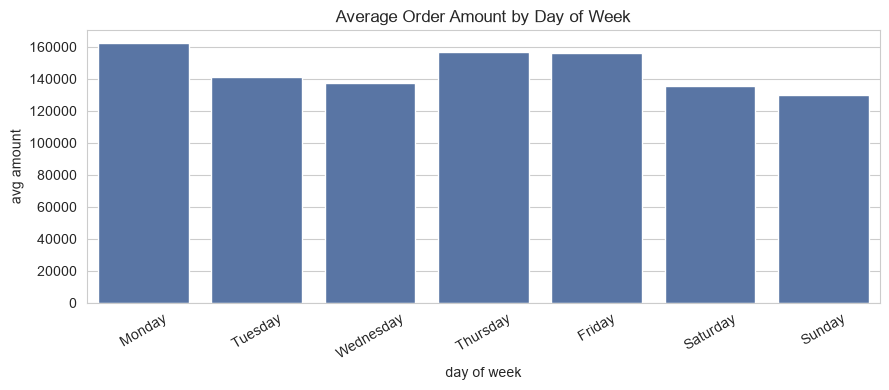

In [24]:
# [도식] 요일별 평균 매출 막대그래프 — 부품이 곧 인사이트가 된다
plt.figure(figsize=(9, 4))
sns.barplot(x=dow_sales.index, y=dow_sales.values, color="#4C72B0")
plt.title("Average Order Amount by Day of Week")
plt.xlabel("day of week"); plt.ylabel("avg amount")
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

In [27]:
# 스스로 해보자! (5)
# 아래 주석(#)을 지우고 빈칸(___)을 채워보세요.

# 1) 시간대별 주문 건수
print(valid["hour"].value_counts().sort_index())              # value_counts

# 2) 주말 주문 비율
weekend = valid[valid["dow_num"] >= 5]               # >= 5 (토=5, 일=6)
print("주말 주문 비율:", round(len(weekend) / len(valid) * 100, 1), "%")

# "심야(0~6시) 주문 비중"을 알고 싶다면 어떤 부품과 조건을 쓰면 될까요?
night = valid[valid["hour"].isin([0, 1, 2, 3, 4, 5, 6])]
print("심야 주문 비율:", round(len(night) / len(valid) * 100, 1), "%")

hour
0      87
1      85
2      73
3      80
4      94
5     103
6      89
7      74
8      90
9      64
10     79
11     91
12     82
13     77
14     78
15     91
16    108
17     76
18     72
19     84
20     88
21     69
22     75
23     79
Name: count, dtype: int64
주말 주문 비율: 27.5 %
심야 주문 비율: 30.7 %



### 문자열의 .str에 대응하는, 날짜의 접근자는 무엇인가요?
- .dt

### .dt.dayofweek에서 0과 5는 각각 무슨 요일인가요?
- 0은 월요일, 5는 토요일

### .dt로 꺼낸 부품을 groupby에 넣으면 무엇을 할 수 있나요?
- 날짜 유형 별로 데이터 계산을 비교할 수 있다.

In [28]:
# 예제: 일별 매출 합계 (resample 'D')
ts = valid.set_index("order_dt").sort_index()   # 날짜를 인덱스로 + 시간순 정렬

daily_sales = ts["amount"].resample("D").sum()   # 하루 단위 합계
print("일별 매출 (앞 7일):")
print(daily_sales.head(7))
print("\n총 일수:", len(daily_sales))

일별 매출 (앞 7일):
order_dt
2025-01-01    2364000
2025-01-02    3206000
2025-01-03    2079000
2025-01-04    2810000
2025-01-05    2468000
2025-01-06    2994000
2025-01-07    3373000
Freq: D, Name: amount, dtype: int64

총 일수: 90


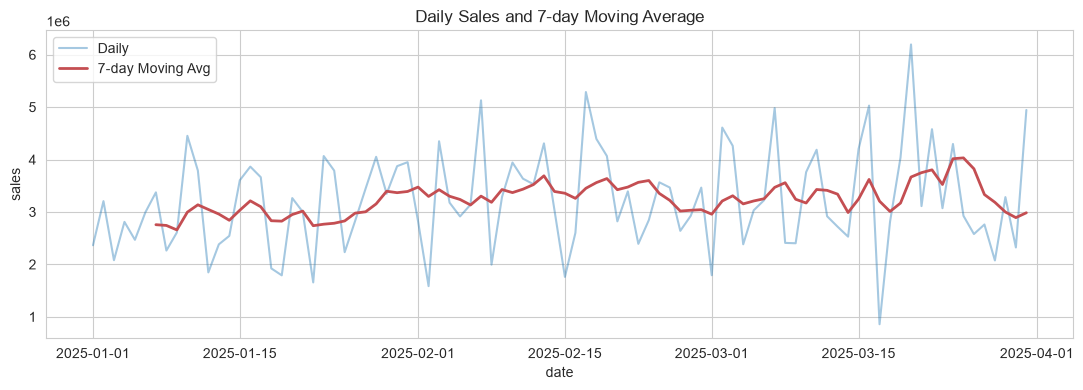

In [29]:
# 예제: 이동평균(rolling) — 들쭉날쭉한 일 매출을 7일 평균으로 부드럽게
daily_ma7 = daily_sales.rolling(7).mean()        # 최근 7일 이동평균

plt.figure(figsize=(11, 4))
plt.plot(daily_sales.index, daily_sales.values, alpha=0.4, label="Daily")
plt.plot(daily_ma7.index, daily_ma7.values, color="#C44E52", linewidth=2, label="7-day Moving Avg")
plt.title("Daily Sales and 7-day Moving Average")
plt.xlabel("date"); plt.ylabel("sales")
plt.legend()
plt.tight_layout(); plt.show()

In [30]:
# 예제: 주 단위로 자를 바꿔보기 (resample 'W')
weekly_sales = ts["amount"].resample("W").sum()
print("[주별 매출]")
print(weekly_sales)

[주별 매출]
order_dt
2025-01-05    12927000
2025-01-12    21327000
2025-01-19    19767000
2025-01-26    20837000
2025-02-02    23068000
2025-02-09    23986000
2025-02-16    22812000
2025-02-23    25194000
2025-03-02    22460000
2025-03-09    22691000
2025-03-16    25338000
2025-03-23    24663000
2025-03-30    20239000
2025-04-06     4945000
Freq: W-SUN, Name: amount, dtype: int64


In [ ]:
# 스스로 해보자! (6)
# 아래 주석(#)을 지우고 빈칸(___)을 채워보세요.

# 1) 시간대별 주문 건수
hourly = ts["amount"].resample("h").count()    # 힌트: "h"
print(hourly.head(24))

# 2) 3일 이동평균 vs 7일 이동평균
ma3 = daily_sales.rolling(3).mean()            # 힌트: 3
print(pd.DataFrame({"daily": daily_sales, "ma3": ma3, "ma7": daily_ma7}).head(10))

# "월별 매출"을 보고 싶다면 빈도 문자로 무엇을 써야 할까요?
# 월별은 "ME"(month end) 또는 "MS"(month start)를 씁니다. ts["amount"].resample("ME").sum().

order_dt
2025-01-01 00:00:00    2
2025-01-01 01:00:00    0
2025-01-01 02:00:00    1
2025-01-01 03:00:00    0
2025-01-01 04:00:00    2
2025-01-01 05:00:00    1
2025-01-01 06:00:00    1
2025-01-01 07:00:00    3
2025-01-01 08:00:00    0
2025-01-01 09:00:00    0
2025-01-01 10:00:00    0
2025-01-01 11:00:00    2
2025-01-01 12:00:00    0
2025-01-01 13:00:00    0
2025-01-01 14:00:00    1
2025-01-01 15:00:00    1
2025-01-01 16:00:00    1
2025-01-01 17:00:00    0
2025-01-01 18:00:00    0
2025-01-01 19:00:00    0
2025-01-01 20:00:00    2
2025-01-01 21:00:00    1
2025-01-01 22:00:00    1
2025-01-01 23:00:00    1
Freq: h, Name: amount, dtype: int64
              daily           ma3           ma7
order_dt                                       
2025-01-01  2364000           NaN           NaN
2025-01-02  3206000           NaN           NaN
2025-01-03  2079000  2.549667e+06           NaN
2025-01-04  2810000  2.698333e+06           NaN
2025-01-05  2468000  2.452333e+06           NaN
2025-01-06  2994000

### resample을 쓰기 전에 반드시 해야 하는 준비는 무엇인가요? (힌트: 인덱스)
- resample은 날짜가 인덱스(index) 여야 동작합니다. 그래서 set_index("order_dt")로 날짜를 인덱스로 올린 뒤 씁니다.

### "D", "W", "h"는 각각 어떤 시간 단위인가요?
▸ 데이(하루), 위크(1주), 아워(1시간)
### 이동평균(rolling)은 무엇을 위해 쓰며, 창(window)을 키우면 그래프가 어떻게 변하나요?
추세를 설명할 때는 이동평균. 들쭉날쭉하게 변함

In [7]:
# 웹 서버 접속 로그 생성 (가상) — 한 줄이 통째로 문자열
np.random.seed(7)
n_logs = 1500
ips = [f"203.0.113.{k}" for k in range(1, 60)] + [f"198.51.100.{k}" for k in range(1, 60)]
paths = ["/", "/products", "/products/123", "/products/456", "/cart",
         "/checkout", "/login", "/search", "/api/orders"]
methods = ["GET", "GET", "GET", "POST"]
statuses = [200, 200, 200, 200, 200, 404, 500, 301]

# 시각: 7일치, 초 단위로 무작위 발생 후 정렬
log_times = pd.to_datetime("2025-03-01") + pd.to_timedelta(
    np.sort(np.random.randint(0, 7 * 24 * 3600, n_logs)), unit="s")

lines = []
for i in range(n_logs):
    ip = np.random.choice(ips)
    ts_str = log_times[i].strftime("%d/%b/%Y:%H:%M:%S")   # 12/Jan/2025:10:15:32
    m = np.random.choice(methods)
    p = np.random.choice(paths)
    st = np.random.choice(statuses)
    sz = np.random.randint(200, 5000)
    lines.append(f'{ip} - - [{ts_str}] "{m} {p} HTTP/1.1" {st} {sz}')

web_logs = pd.DataFrame({"raw": lines})
print("웹 로그 생성 완료:", web_logs.shape)
print("\n[원본 로그 한 줄은 이렇게 생겼습니다]")
for line in web_logs["raw"].head(3):
    print(line)

웹 로그 생성 완료: (1500, 1)

[원본 로그 한 줄은 이렇게 생겼습니다]
203.0.113.39 - - [01/Mar/2025:00:01:14] "GET / HTTP/1.1" 200 2371
198.51.100.21 - - [01/Mar/2025:00:02:24] "GET / HTTP/1.1" 301 284
198.51.100.17 - - [01/Mar/2025:00:02:28] "GET /search HTTP/1.1" 200 1448


In [8]:
# 시나리오 1 — 정규식으로 6개 필드를 한 번에 추출
pattern = (
    r"(?P<ip>\d+\.\d+\.\d+\.\d+)"        # IP: 숫자.숫자.숫자.숫자
    r" - - \["                            # 고정 구분 부분
    r"(?P<ts>[^\]]+)"                     # 시각: ] 가 아닌 글자들
    r"\] \""                              # ] 와 따옴표
    r"(?P<method>\w+) "                   # 방식: GET/POST
    r"(?P<path>\S+)"                      # 경로: 공백 아닌 글자들
    r"[^\"]*\" "                          # HTTP/1.1 부분 건너뛰기
    r"(?P<status>\d+) "                   # 상태 코드
    r"(?P<size>\d+)"                      # 응답 크기
)
logs = web_logs["raw"].str.extract(pattern)
print("추출된 표:", logs.shape)
print(logs.head())
print("\n추출 실패(어느 한 칸이라도 NaN) 행 수:", logs.isna().any(axis=1).sum())

print("가장 늦은 주문:", logs["ts"].max())


추출된 표: (1500, 6)
              ip                    ts method       path status  size
0   203.0.113.39  01/Mar/2025:00:01:14    GET          /    200  2371
1  198.51.100.21  01/Mar/2025:00:02:24    GET          /    301   284
2  198.51.100.17  01/Mar/2025:00:02:28    GET    /search    200  1448
3   203.0.113.35  01/Mar/2025:00:03:56    GET      /cart    404  3921
4   203.0.113.47  01/Mar/2025:00:14:29    GET  /products    500  2580

추출 실패(어느 한 칸이라도 NaN) 행 수: 0
가장 늦은 주문: 07/Mar/2025:23:42:41


In [9]:
# 시나리오 2 — 타입 정리(날짜·숫자) + dt 부품
logs["ts"] = pd.to_datetime(logs["ts"], format="%d/%b/%Y:%H:%M:%S", errors="coerce")
logs["status"] = logs["status"].astype(int)
logs["size"] = logs["size"].astype(int)

# dt 부품: 시각(hour)과 요일
logs["hour"] = logs["ts"].dt.hour
logs["dow_name"] = logs["ts"].dt.day_name()

print("정리 후 자료형:")
print(logs.dtypes)
print()
print(logs[["ip", "ts", "method", "path", "status", "hour", "dow_name"]].head())

정리 후 자료형:
ip                     str
ts          datetime64[us]
method                 str
path                   str
status               int64
size                 int64
hour                 int32
dow_name               str
dtype: object

              ip                  ts method       path  status  hour  dow_name
0   203.0.113.39 2025-03-01 00:01:14    GET          /     200     0  Saturday
1  198.51.100.21 2025-03-01 00:02:24    GET          /     301     0  Saturday
2  198.51.100.17 2025-03-01 00:02:28    GET    /search     200     0  Saturday
3   203.0.113.35 2025-03-01 00:03:56    GET      /cart     404     0  Saturday
4   203.0.113.47 2025-03-01 00:14:29    GET  /products     500     0  Saturday


In [10]:
# 시나리오 2 — 상태 코드·인기 경로 빠르게 집계
print("[상태 코드 분포]")
print(logs["status"].value_counts())
print(logs["status"].value_counts().sum())

error_rate = (logs["status"] >= 400).mean() * 100   # 4xx·5xx 비율
print(f"\n오류 응답(4xx·5xx) 비율: {error_rate:.1f}%")

print("\n[요청이 많은 경로 TOP 5]")
print(logs["path"].value_counts().head(3))

[상태 코드 분포]
status
200    964
301    188
404    178
500    170
Name: count, dtype: int64
1500

오류 응답(4xx·5xx) 비율: 23.2%

[요청이 많은 경로 TOP 5]
path
/          184
/search    175
/cart      173
Name: count, dtype: int64


dow_num
0    221
1    215
2    198
3    225
4    221
5    212
6    208
Name: count, dtype: int64


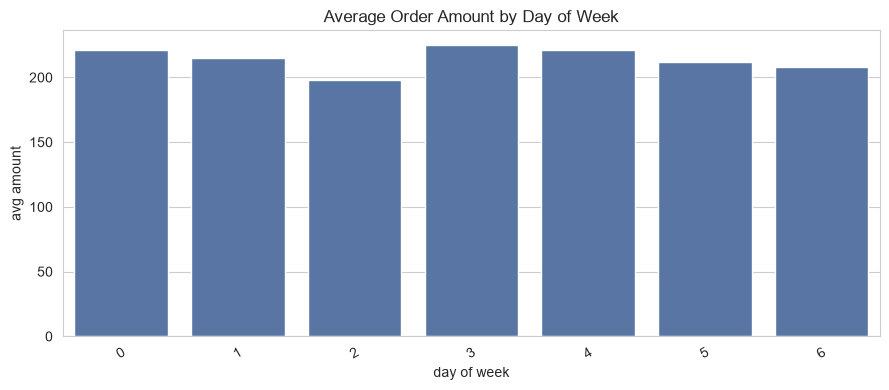

In [14]:
# 시나리오 3 — 요일별 트래픽 (resample 'h')
logs_days = logs["dow_num"] = logs["ts"].dt.dayofweek
print(logs["dow_num"].value_counts().sort_index())

plt.figure(figsize=(9, 4))
sns.barplot(x=logs_days.value_counts().sort_index().index, y=logs_days.value_counts().sort_index().values, color="#4C72B0")
plt.title("Average Order Amount by Day of Week")
plt.xlabel("day of week"); plt.ylabel("avg amount")
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()


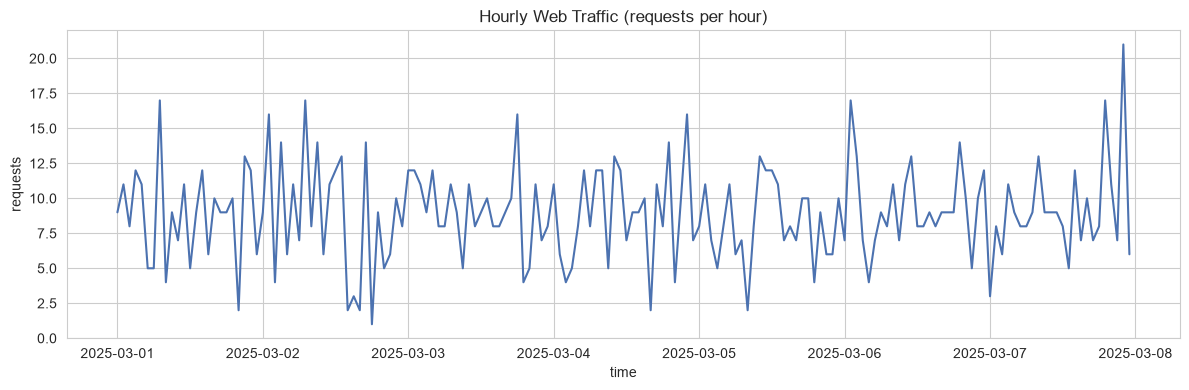

가장 트래픽이 많았던 시간대 TOP 3:
ts
2025-03-07 22:00:00    21
2025-03-01 07:00:00    17
2025-03-06 01:00:00    17
Name: ip, dtype: int64


In [15]:
# 시나리오 3 — 요일별 트래픽 (resample 'h')
log_dow = logs.dropna(subset=["ts"]).set_index("ts").sort_index()
hourly_traffic = log_dow["ip"].resample("h").count()    # 시간당 요청 수

plt.figure(figsize=(12, 4))
plt.plot(hourly_traffic.index, hourly_traffic.values, color="#4C72B0")
plt.title("Hourly Web Traffic (requests per hour)")
plt.xlabel("time"); plt.ylabel("requests")
plt.tight_layout(); plt.show()

print("가장 트래픽이 많았던 시간대 TOP 3:")
print(hourly_traffic.sort_values(ascending=False).head(3))